In [2]:
import holidays

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from geopy.distance import geodesic #mide distancia a partir de longitud y latitud

In [3]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [4]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [5]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [6]:
df.info()
df_copy = df.copy()
# Encontramos valores nulos en las columnas 'dropoff_longitude' y 'dropoff_latitude'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [7]:
df.isnull().sum()

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

# Cantidad de Pasajeros
-------------

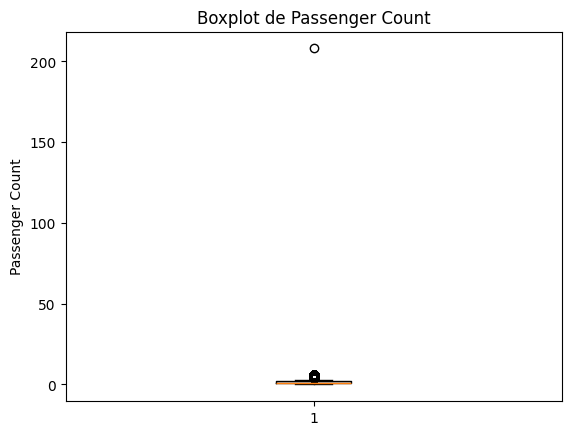

In [8]:
# Box plot de los datos de la variable Cantidad de Pasajeros
plt.boxplot(df['passenger_count'])
plt.title('Boxplot de Passenger Count')
plt.ylabel('Passenger Count')
plt.show()

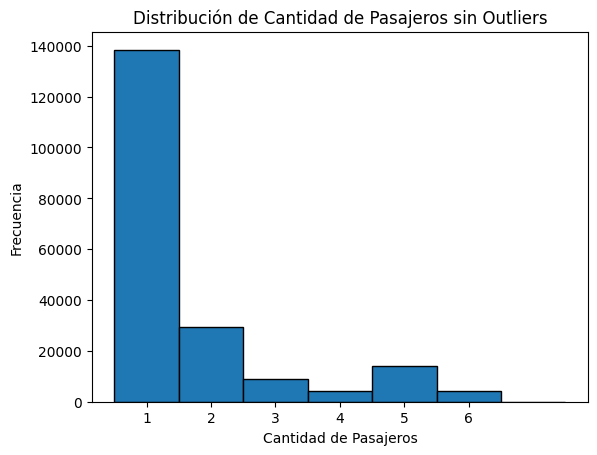

In [9]:
# Eliminamos registros con valores mayores a 6
df_copy = df_copy[df_copy['passenger_count'] <= 6]

# Visualizamos la distribucion de la variable 'passenger_count' sin outliers
plt.hist(df_copy['passenger_count'], bins=range(1, 9), edgecolor='black', align='left')
plt.title('Distribución de Cantidad de Pasajeros sin Outliers')
plt.xlabel('Cantidad de Pasajeros')
plt.ylabel('Frecuencia')
plt.xticks(range(1, 7))
plt.show()

/var/folders/l1/5h810w6x4hz_8yc4sfqwjlkr0000gn/T/ipykernel_7607/2961094499.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promedios, x='Cantidad de Pasajeros', y='Promedio Precio', palette='viridis')


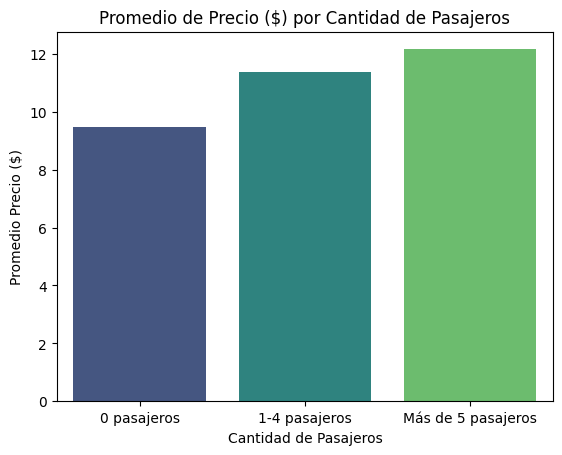

In [10]:
'''
Calculamos y visualizamos el promedio de la variable 'fare_amount' para los diferentes servicios de Uber según cantidad de pasajeros.
- 0 pasajeros
- 1-4 pasajeros
- Más de 5 pasajeros
'''


prom56 = df_copy[df_copy['passenger_count'] > 5]['fare_amount'].mean()
prom0 = df_copy[df_copy['passenger_count'] == 0]['fare_amount'].mean()
prom14 = df_copy[(df_copy['passenger_count'] >= 1) & (df_copy['passenger_count'] <= 4)]['fare_amount'].mean()

promedios = pd.DataFrame({
    'Cantidad de Pasajeros': ['0 pasajeros', '1-4 pasajeros', 'Más de 5 pasajeros'],
    'Promedio Precio': [prom0, prom14, prom56]
})

sns.barplot(data=promedios, x='Cantidad de Pasajeros', y='Promedio Precio', palette='viridis')
plt.title('Promedio de Precio ($) por Cantidad de Pasajeros')
plt.ylabel('Promedio Precio ($)')
plt.xlabel('Cantidad de Pasajeros')
plt.show();


In [11]:
'''
Eliminamos los valores de la columna 'passenger_count' que sean mayores a 7  ya que es el máximo permitido en los vehiculos de la flota de Uber.

Luego creamos variables Dummies para los tipos de servicio de Uber:
- Uber Eats (0 pasajeros)
- Uber Normal (1 a 5 pasajeros)
- Uber XL (6 pasajeros o más)
'''


# Crear columnas booleanas
df_copy['uber_eats'] = (df_copy['passenger_count'] == 0).astype(int)
df_copy['uber_normal'] = ((df_copy['passenger_count'] >= 1) & (df_copy['passenger_count'] <= 5)).astype(int)
df_copy['uber_xl'] = (df_copy['passenger_count'] >= 6).astype(int)

# Fecha
--------------

In [12]:
'''
En la variable 'pickup_datetime' observamos que los valores se encuentran en rangos normales,
por lo que no realizamos ninguna modificacion
'''
df_copy['pickup_datetime'].describe()

count                      199999
unique                     196628
top       2009-02-12 12:46:00 UTC
freq                            4
Name: pickup_datetime, dtype: object

In [13]:
'''
Convertimos la columna 'pickup_datetime' a tipo datetime,
para luego poder dividir los datos en
- Año
- Mes
- Día
- Hora
- Día de la semana (0 = Lunes, 6 = Domingo)
- Viernes (0 = No, 1 = Si)
- Sábado (0 = No, 1 = Si)
- Domingo o Jueves (0 = No, 1 = Si)
'''

df_copy['pickup_datetime'] = pd.to_datetime(df_copy['pickup_datetime'])

df_copy["year"] = df_copy["pickup_datetime"].dt.year
df_copy["month"] = df_copy["pickup_datetime"].dt.month
df_copy["day"] = df_copy["pickup_datetime"].dt.day
df_copy["hour"] = df_copy["pickup_datetime"].dt.hour

df_copy["weekday"] = df_copy["pickup_datetime"].dt.weekday  # 0 = Lunes, 6 = Domingo

In [14]:

# Crear un objeto con los feriados en EE.UU.
us_holidays = holidays.US()

'''
Agregamos una columna con los dias feriados en EE.UU.
- 0 = No es feriado
- 1 = Es feriado
'''
df_copy['feriado'] = df_copy['pickup_datetime'].dt.date.apply(lambda x: 1 if x in us_holidays else 0)
df_copy['feriado'].value_counts()

feriado
0    195475
1      4524
Name: count, dtype: int64

## Visualización de las nuevas columnas creadas
-----

/var/folders/l1/5h810w6x4hz_8yc4sfqwjlkr0000gn/T/ipykernel_7607/3943787133.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promedio_dia_semana, x='weekday', y='fare_amount', palette='magma', ax=axes[0])
/var/folders/l1/5h810w6x4hz_8yc4sfqwjlkr0000gn/T/ipykernel_7607/3943787133.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promedio_por_hora, x='Hora', y='Costo Promedio', palette='viridis', ax=axes[1])


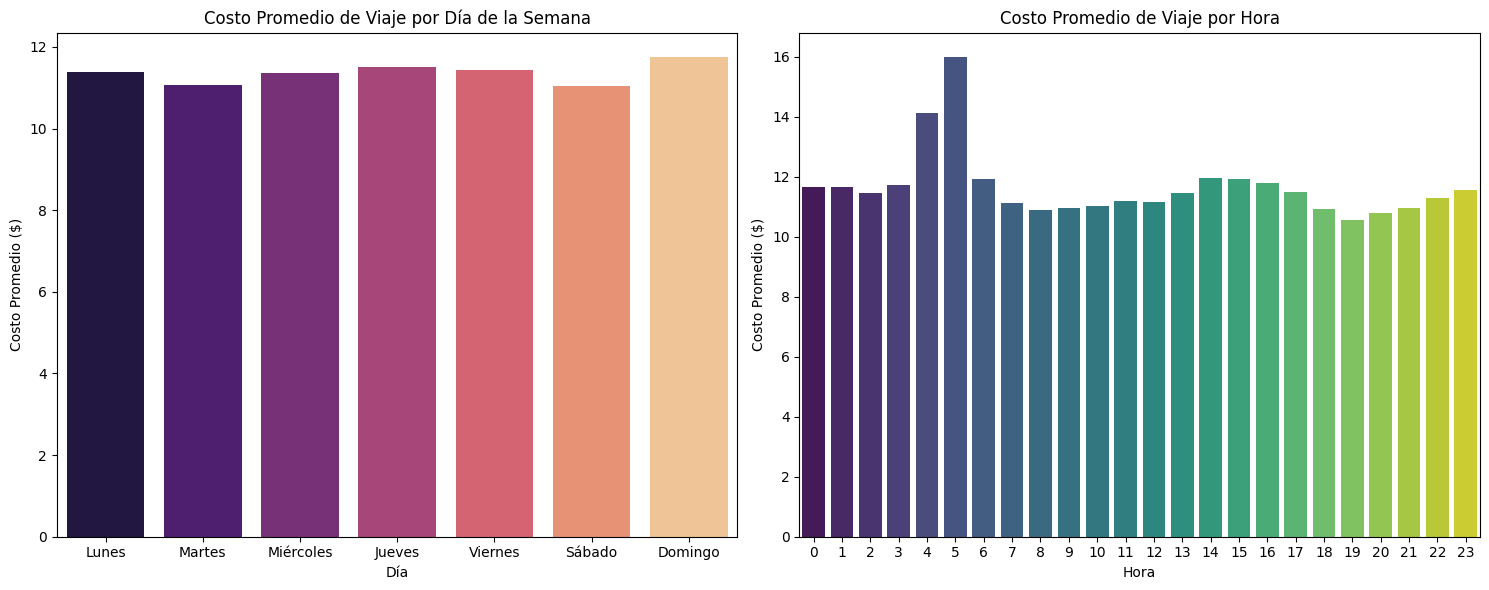

In [15]:
promedio_dia_semana = df_copy.groupby('weekday')['fare_amount'].mean().reset_index()

# Calculamos el costo promedio de viaje por hora
promedio_por_hora = df_copy.groupby('hour')['fare_amount'].mean().reset_index()
promedio_por_hora.columns = ['Hora', 'Costo Promedio']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico del costo promedio de viaje por día de la semana
sns.barplot(data=promedio_dia_semana, x='weekday', y='fare_amount', palette='magma', ax=axes[0])
axes[0].set_title('Costo Promedio de Viaje por Día de la Semana')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Costo Promedio ($)')
axes[0].set_xticks(range(0, 7))
axes[0].set_xticklabels(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])

# Gráfico del costo promedio de viaje por hora
sns.barplot(data=promedio_por_hora, x='Hora', y='Costo Promedio', palette='viridis', ax=axes[1])
axes[1].set_title('Costo Promedio de Viaje por Hora')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Costo Promedio ($)')
axes[1].set_xticks(range(0, 24))

# Ajustar el espacio entre los subplots
plt.tight_layout()
plt.show();

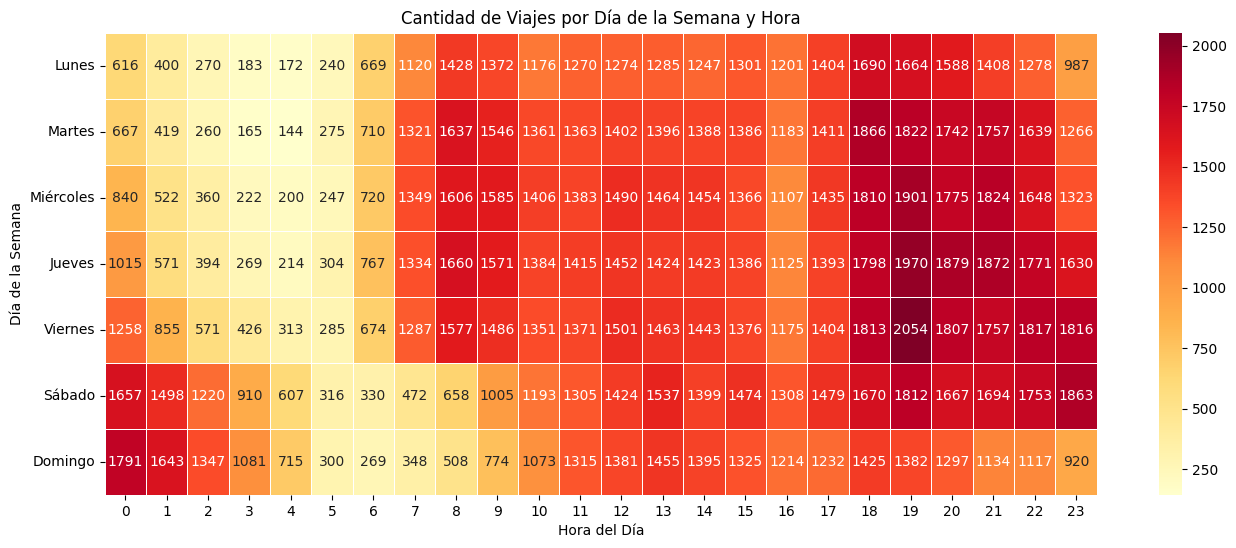

In [16]:
viajes_por_dia_hora = df_copy.groupby(['weekday', 'hour']).size().reset_index(name='cantidad_viajes')

# Pivotamos para tener días como filas y horas como columnas
heatmap_data = viajes_por_dia_hora.pivot(index='weekday', columns='hour', values='cantidad_viajes')

# Ordenamos los días para que vaya de lunes a domingo
heatmap_data = heatmap_data.reindex([0, 1, 2, 3, 4, 5, 6])

# Mapa de calor
plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=.5, annot=True, fmt=".0f")
plt.title('Cantidad de Viajes por Día de la Semana y Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.yticks(ticks=[0.5+i for i in range(7)], labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'], rotation=0)
plt.show()

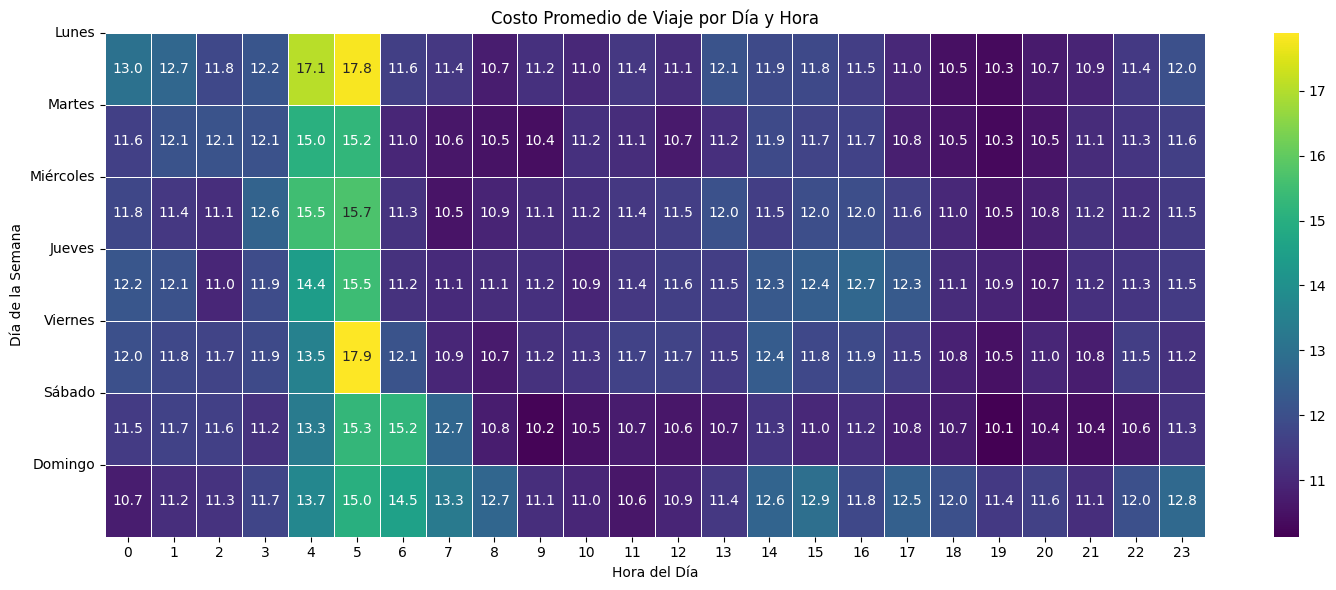

In [17]:
# Agrupamos por día de la semana y hora y calculamos el costo promedio
viajes_por_dia_hora = df_copy.groupby(['weekday', 'hour'])['fare_amount'].mean().reset_index(name='costo_promedio')

# Convertimos a formato de tabla (día como filas, hora como columnas)
tabla_heatmap = viajes_por_dia_hora.pivot(index='weekday', columns='hour', values='costo_promedio')

# Creamos el heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(tabla_heatmap, cmap='viridis', annot=True, fmt=".1f", linewidths=.5)

# Etiquetas personalizadas
plt.title('Costo Promedio de Viaje por Día y Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.yticks(ticks=range(7), labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'], rotation=0)

plt.tight_layout()
plt.show()

# ¿Hora, año y mes debemos usar one-hot encoding?
----------
### Año (cuantitativo discreto)
Se puede usar directamente como una variable numérica en la regresión.
Ejemplo: 2023, 2024, 2025.
### Mes (categórico ordinal o numérico discreto)
Probar representandolo como numero
### Día de la semana (categórico nominal)
No tiene un valor numérico natural, por lo que debe codificarse como variables dummy (one-hot encoding).
Ejemplo:
lunes=1, martes=0, ..., domingo=0.
### Día del mes (cuantitativo discreto)
Se puede usar como un número directamente (1 al 31).
No es necesario hacer one-hot encoding.
### Hora
Probar como variable continua o agrupar segun franja horaria
df["franja_horaria"] = pd.cut(df["hora"], bins=[0, 6, 12, 18, 24], labels=["madrugada", "mañana", "tarde", "noche"])
df = pd.get_dummies(df, columns=["franja_horaria"])

----


/var/folders/l1/5h810w6x4hz_8yc4sfqwjlkr0000gn/T/ipykernel_7607/2050568071.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promedio_por_anio, x='Año', y='Costo Promedio', palette='magma', ax=axes[0])
/var/folders/l1/5h810w6x4hz_8yc4sfqwjlkr0000gn/T/ipykernel_7607/2050568071.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promedio_por_mes, x='Mes', y='Costo Promedio', palette='viridis', ax=axes[1])


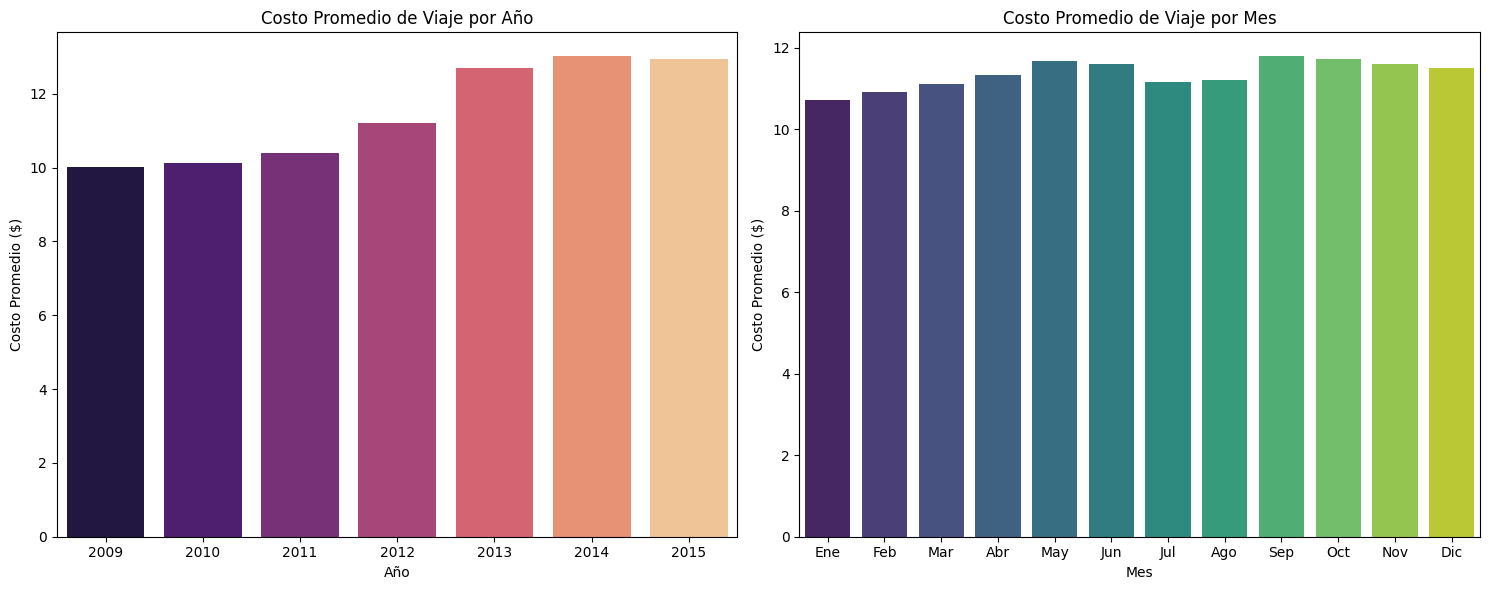

In [18]:
# Calculamos el costo promedio de viaje por mes
promedio_por_mes = df_copy.groupby('month')['fare_amount'].mean().reset_index()
promedio_por_mes.columns = ['Mes', 'Costo Promedio']

# Calculamos el costo promedio de viaje por año
promedio_por_anio = df_copy.groupby('year')['fare_amount'].mean().reset_index()
promedio_por_anio.columns = ['Año', 'Costo Promedio']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=promedio_por_anio, x='Año', y='Costo Promedio', palette='magma', ax=axes[0])
axes[0].set_title('Costo Promedio de Viaje por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Costo Promedio ($)')

sns.barplot(data=promedio_por_mes, x='Mes', y='Costo Promedio', palette='viridis', ax=axes[1])
axes[1].set_title('Costo Promedio de Viaje por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Costo Promedio ($)')
axes[1].set_xticks(range(0, 12))
axes[1].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

plt.tight_layout()
plt.show();

In [19]:
df_copy["weekend"] = ((df_copy["weekday"] == 6) | (df_copy['weekday'] == 5)).astype(int)
# One-hot encoding para la variable 'weekday'
df_copy = pd.get_dummies(df_copy, columns=['weekday'], prefix='weekday', dtype=int)

# Variables de Posición Geográfica
-----------

In [20]:
'''
Eliminamos los viajes en donde la latitud de origen o destino sea menor a -55.95 o mayor a 70.75,
ya que estaría fuera de los límites en los que Uber opera sus viajes
'''
df_copy = df_copy[(df_copy['pickup_latitude'] > -55.95) & (df_copy['pickup_latitude'] < 70.75)]
df_copy = df_copy[(df_copy['dropoff_latitude'] > -55.95) & (df_copy['dropoff_latitude'] < 70.75)]

In [21]:
'''
Eliminamos los datos de longitud de origen o destino mayores a 180 o menores a -180,
ya que no representan coordenadas reales
'''
df_copy = df_copy[(df_copy['pickup_longitude'] > -180) & (df_copy['dropoff_longitude'] > -180)]
df_copy = df_copy[(df_copy['pickup_longitude'] < 180) & (df_copy['dropoff_longitude'] < 180)]



### Deberiamos probar de crear una variable distancia

In [22]:
def calcular_distancia(row):
    pickup = (row['pickup_latitude'], row['pickup_longitude'])
    dropoff = (row['dropoff_latitude'], row['dropoff_longitude'])
    return geodesic(pickup, dropoff).kilometers

# Agregar la columna 'distance' al DataFrame
df_copy['distance'] = df_copy.apply(calcular_distancia, axis=1)

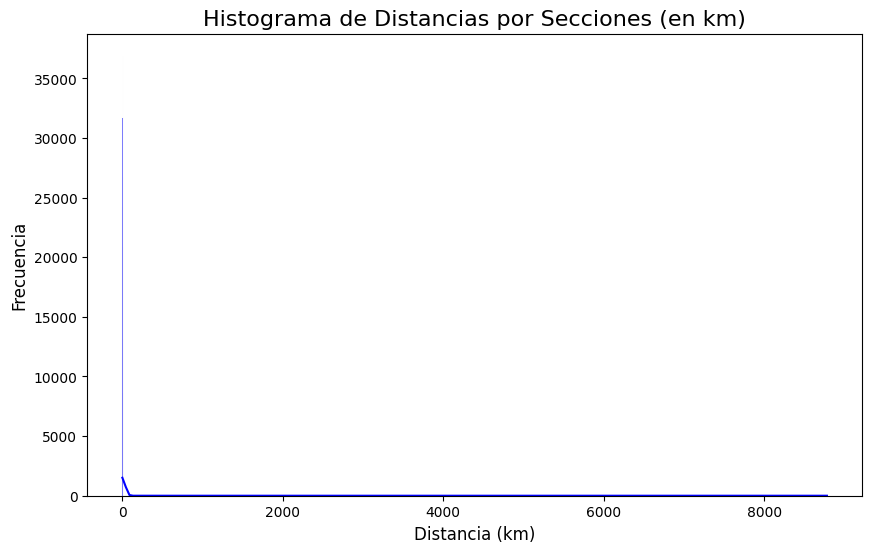

In [23]:
bins = [0, 0.5, 1, 1.5, 2, 3, 4, 5, 6]  # Por ejemplo, intervalos de 0.5 km

# Crear el histograma con los bins definidos
plt.figure(figsize=(10, 6))
sns.histplot(df_copy['distance'], bins=bins, kde=True, color='blue')

# Añadir etiquetas y título
plt.title('Histograma de Distancias por Secciones (en km)', fontsize=16)
plt.xlabel('Distancia (km)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Mostrar gráfico
plt.show()

# Viajes con distancia = 0

In [24]:
count_zero_distance = (df_copy['distance'] == 0).sum()
print(f'Cantidad de viajes con distancia igual a 0: {count_zero_distance}')

Cantidad de viajes con distancia igual a 0: 5630


In [25]:
# Filtrar los viajes con distancia cero
viajes_distancia_cero = df_copy[df_copy['distance'] == 0]

# Mostrar solo la columna fare_amount
viajes_distancia_cero['fare_amount']

5          4.9
7          2.5
11         8.5
48        56.8
65         6.0
          ... 
199880     6.5
199883    12.5
199917     4.5
199932    24.9
199963    39.0
Name: fare_amount, Length: 5630, dtype: float64

# Precio
---------------

In [26]:
'''
Observamos que en la columna fare_amount se registran valores negativos,
al ser una variable que permite valores negativos, eliminamos los registros con valores negativos
'''
df['fare_amount'].describe()

count    200000.000000
mean         11.359955
std           9.901776
min         -52.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

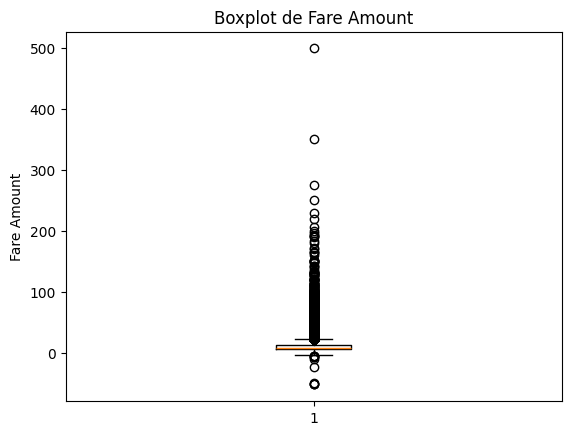

In [27]:
plt.boxplot(df_copy['fare_amount'])
plt.title('Boxplot de Fare Amount')
plt.ylabel('Fare Amount')
plt.show()


In [28]:
# Winsorizing fare_amount
p1 = df_copy['fare_amount'].quantile(0.01)
p99 = df_copy['fare_amount'].quantile(0.99)
mediana = df['fare_amount'].median()

df_copy['fare_amount'] = df_copy['fare_amount'].apply(
    lambda x: mediana if x < p1 or x > p99 else x
)


In [29]:
print(f'Cantidad de datos previos a la limpieza: {df.shape[0]}')
print(f'Cantidad de datos posteriores a la limpieza: {df_copy.shape[0]}')

Cantidad de datos previos a la limpieza: 200000
Cantidad de datos posteriores a la limpieza: 199884


In [30]:
df_copy['fare_amount'].describe()

count    199884.000000
mean         10.846969
std           7.980239
min           3.300000
25%           6.100000
50%           8.500000
75%          12.500000
max          53.300000
Name: fare_amount, dtype: float64

In [31]:
df_copy["distance"].describe()

count    199884.000000
mean         20.572281
std         379.761346
min           0.000000
25%           1.215692
50%           2.121467
75%           3.874471
max        8783.593498
Name: distance, dtype: float64

# Imputamos por la mediana los outliers de Distancia

In [32]:
# Calculamos los percentiles y el IQR
q1 = df_copy['distance'].quantile(0.25)
q3 = df_copy['distance'].quantile(0.75)
iqr = q3 - q1

# Definimos los límites
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Calculamos la mediana
mediana_distance = df_copy['distance'].median()

# Reemplazamos los outliers por la mediana
df_copy['distance'] = df_copy['distance'].apply(
    lambda x: mediana_distance if x < limite_inferior or x > limite_superior else x
)

df_copy['distance'].describe()

count    199884.000000
mean          2.372917
std           1.628533
min           0.000000
25%           1.215692
50%           2.121463
75%           3.076233
max           7.862549
Name: distance, dtype: float64

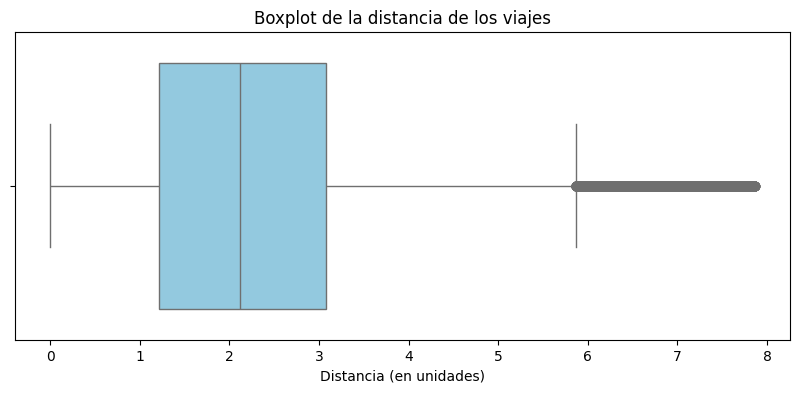

In [33]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_copy, x='distance', color='skyblue')
plt.title('Boxplot de la distancia de los viajes')
plt.xlabel('Distancia (en unidades)')
plt.show()

# Probando Cosas

In [34]:
# Ver el tema de los registros de distancia 0
# eliminar la columna key ya que no aporta en nada
# ver grafico de correlacion, para ver si hay variables que no nos sirven

In [35]:
# Teniendo en cuenta que la cantidad de viajes con distancia = 0 es de 5629 y esto representa aprox. un 2.8% del DataFrame.
# Decidimos eliminar estos registros, ya que no son coherentes con la lógica del problema y podrían afectar negativamente el rendimiento del modelo.
df_copy = df_copy[df_copy['distance'] != 0]
df_copy.shape[0]


194254

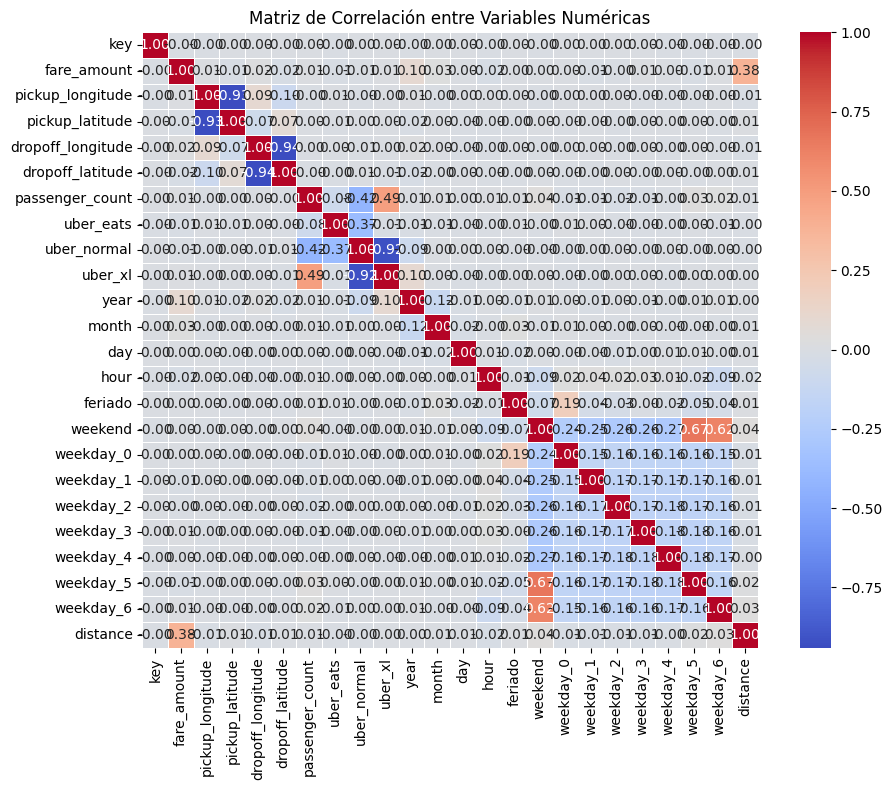

In [36]:
# Tema de correlacion, ver si hay que eliminar varibles a partir de esto.


# Calculamos la matriz de correlación solo con las variables numéricas
correlation_matrix = df_copy.corr(numeric_only=True)

# Creamos el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

plt.title('Matriz de Correlación entre Variables Numéricas')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [37]:
# Creamos una nueva columna 'hour_shifted': a las horas menores a 3 se les suma 24
df_copy['hour_shifted'] = df_copy['hour'].apply(lambda x: x + 24 if x < 3 else x)

# Definimos los bins para la columna transformada
bins = [3, 6, 14, 18, 27]  # Nota: 27 equivale a 3 con la transformación (3 + 24)
labels = ["madrugada", "mañana", "tarde", "noche"]

# Creamos la columna 'franja_horaria' usando pd.cut sobre la columna transformada
df_copy["franja_horaria"] = pd.cut(df_copy["hour_shifted"], bins=bins, labels=labels, right=False)

# Si luego se desea utilizar one-hot encoding:
df_copy = pd.get_dummies(df_copy, columns=["franja_horaria"], dtype=int)

In [38]:
df_copy.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,uber_eats,...,weekday_3,weekday_4,weekday_5,weekday_6,distance,hour_shifted,franja_horaria_madrugada,franja_horaria_mañana,franja_horaria_tarde,franja_horaria_noche
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,0,...,1,0,0,0,1.681111,19,0,0,0,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,0,...,0,1,0,0,2.454363,20,0,0,0,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,0,...,0,0,0,0,5.039603,21,0,0,0,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,0,...,0,1,0,0,1.661442,8,0,1,0,0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,0,...,1,0,0,0,4.483730,17,0,0,1,0


In [39]:
df_copy.corr(numeric_only=True)["fare_amount"].sort_values(ascending=False)

fare_amount                 1.000000
distance                    0.380670
year                        0.095596
franja_horaria_madrugada    0.042133
month                       0.027214
dropoff_longitude           0.017184
passenger_count             0.014593
franja_horaria_tarde        0.014388
pickup_longitude            0.014374
uber_xl                     0.011769
weekday_6                   0.011739
weekday_3                   0.007644
day                         0.002244
weekday_4                   0.002024
feriado                     0.001647
weekday_0                   0.000490
weekend                     0.000227
key                        -0.000769
weekday_2                  -0.001509
uber_normal                -0.006604
hour_shifted               -0.006620
weekday_1                  -0.009183
weekday_5                  -0.010804
uber_eats                  -0.011314
franja_horaria_noche       -0.012504
pickup_latitude            -0.012899
franja_horaria_mañana      -0.015721
d

In [40]:
# Definir features y target
features = [
    'distance',
    'year',
    'month',
    'feriado',
    'weekend',
    'franja_horaria_madrugada',
    'franja_horaria_mañana',
    'franja_horaria_noche',
    'uber_xl',
    'uber_eats'
]
target = 'fare_amount'

# Separar en conjuntos de entrenamiento y prueba usando únicamente las features definidas
X_train, X_test, y_train, y_test = train_test_split(df_copy[features], df_copy[target],
                                                    test_size=0.2, random_state=42)

In [41]:
X_train.describe()

,distance,year,month,feriado,weekend,franja_horaria_madrugada,franja_horaria_mañana,franja_horaria_noche,uber_xl,uber_eats
count,155403.000000,155403.000000,155403.000000,155403.000000,155403.000000,155403.000000,155403.000000,155403.000000,155403.000000,155403.000000
mean,2.441213,2011.748885,6.280007,0.022426,0.282922,0.037947,0.340334,0.434606,0.021222,0.003430
std,1.600787,1.860439,3.443643,0.148063,0.450421,0.191068,0.473823,0.495707,0.144125,0.058464
min,0.000084,2009.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.280709,2010.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.121467,2012.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.128140,2013.000000,9.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,7.862549,2015.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Escalado de Datos

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconstruir los DataFrames escalados
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

X_test_scaled.head()

,distance,year,month,feriado,weekend,franja_horaria_madrugada,franja_horaria_mañana,franja_horaria_noche,uber_xl,uber_eats
69074,-1.172015,0.672486,0.499471,-0.15146,-0.628132,-0.198603,-0.718276,1.140586,-0.147249,-0.058665
89614,-0.296178,0.672486,0.499471,-0.15146,-0.628132,-0.198603,-0.718276,1.140586,-0.147249,-0.058665
56187,-1.046111,-0.402533,1.370644,-0.15146,-0.628132,5.035165,-0.718276,-0.876742,-0.147249,-0.058665
155852,-1.113077,-1.477551,0.789862,-0.15146,-0.628132,-0.198603,-0.718276,-0.876742,-0.147249,-0.058665
167881,0.927555,-1.477551,-0.952485,-0.15146,-0.628132,-0.198603,1.392223,-0.876742,-0.147249,-0.058665


# Regresion Lineal

Linear Regression - RMSE: 7.40
Linear Regression - MSE: 54.80
Linear Regression - R2: 0.15


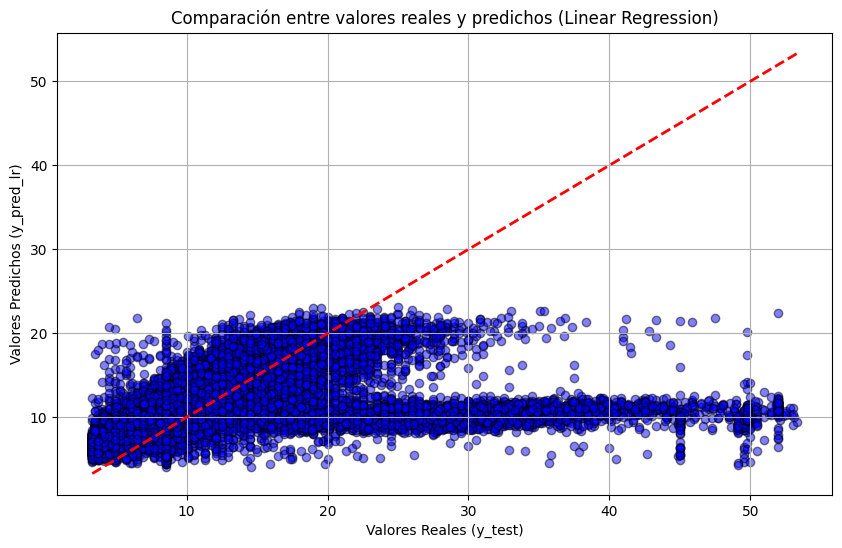

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Creamos el modelo
modelo_lr = LinearRegression()

# Lo entrenamos
modelo_lr.fit(X_train_scaled, y_train)

# Predecimos
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Métricas
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - RMSE: {rmse_lr:.2f}")
print(f"Linear Regression - MSE: {mse_lr:.2f}")
print(f"Linear Regression - R2: {r2_lr:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title('Comparación entre valores reales y predichos (Linear Regression)')
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Valores Predichos (y_pred_lr)')
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Distribución de la variable objetivo (fare_amount)')

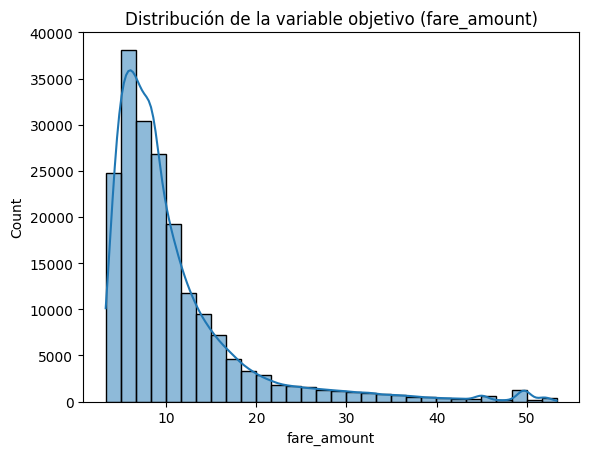

In [45]:
sns.histplot(df_copy['fare_amount'], bins=30, kde=True)
plt.title('Distribución de la variable objetivo (fare_amount)')

# Prueba con Pipelines de Lasso y Ridge

In [44]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Buscamos los mejores hiperparámetros para Ridge y Lasso

ridge = Ridge()
params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, params, scoring='r2', cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print("Mejor alpha Ridge:", ridge_cv.best_params_)
print("Mejor score R2:", ridge_cv.best_score_)


lasso = Lasso(max_iter=10000)
params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso, params, scoring='r2', cv=5)
lasso_cv.fit(X_train_scaled, y_train)

print("Mejor alpha Lasso:", lasso_cv.best_params_)
print("Mejor score R2:", lasso_cv.best_score_)

Mejor alpha Ridge: {'alpha': 10}
Mejor score R2: 0.1594018113619179
Mejor alpha Lasso: {'alpha': 0.001}
Mejor score R2: 0.15940159461189157


In [46]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

X = df_copy[features]
y = df_copy[target]


# Ajustamos el modelo Ridge Cross Validation con los mejores parametros
ridge_pipeline = make_pipeline(
    StandardScaler(),
    RidgeCV(
        alphas=[10],
        cv=5,
        fit_intercept=True
    )
)

ridge_rmse_scores = cross_val_score(ridge_pipeline, X, y,
                                    cv=5, scoring='neg_root_mean_squared_error')
ridge_r2_scores = cross_val_score(ridge_pipeline, X, y, cv=5, scoring='r2')

# Ajustamos el modelo Lasso Cross Validation con los mejores parametros

lasso_pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(
        alphas=[0.001],
        cv=5,
        fit_intercept=True
    )
)
lasso_rmse_scores = cross_val_score(lasso_pipeline, X, y,
                                    cv=5, scoring='neg_root_mean_squared_error')
lasso_r2_scores = cross_val_score(lasso_pipeline, X, y, cv=5, scoring='r2')

print("📈 Ridge CV Results:")
ridge_rmse = -np.mean(ridge_rmse_scores)
ridge_mse = ridge_rmse ** 2
print(f"   RMSE (promedio): {ridge_rmse:.2f}")
print(f"   MSE (promedio): {ridge_mse:.2f}")
print(f"   R² (promedio): {np.mean(ridge_r2_scores):.2f}")

print("\n🧹 Lasso CV Results:")
lasso_rmse = -np.mean(lasso_rmse_scores)
lasso_mse = lasso_rmse ** 2
print(f"   RMSE (promedio): {lasso_rmse:.2f}")
print(f"   MSE (promedio): {lasso_mse:.2f}")
print(f"   R² (promedio): {np.mean(lasso_r2_scores):.2f}")

📈 Ridge CV Results:
   RMSE (promedio): 7.30
   MSE (promedio): 53.35
   R² (promedio): 0.16

🧹 Lasso CV Results:
   RMSE (promedio): 7.30
   MSE (promedio): 53.35
   R² (promedio): 0.16


# Elastic Net

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

# Definimos el modelo con una semilla para reproducibilidad
elastic_net = ElasticNet(random_state=42)

# Definimos el grid de búsqueda para dos hiperparámetros: alpha y l1_ratio
params = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.5, 0.9]  # l1_ratio=0 -> Ridge, l1_ratio=1 -> Lasso
}

elastic_net_cv = GridSearchCV(elastic_net, params, scoring='r2', cv=5)
elastic_net_cv.fit(X_train_scaled, y_train)

print("Mejor alpha Elastic Net:", elastic_net_cv.best_params_['alpha'])
print("Mejor l1_ratio:", elastic_net_cv.best_params_['l1_ratio'])
print("Mejor score R2:", elastic_net_cv.best_score_)

Mejor alpha: 0.01
Mejor l1_ratio: 0.5
Mejor score R2: 0.15939003603104734


In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_val_score
import numpy as np

# Ajustamos el modelo con los mejores hiperaparámetros
enet = ElasticNetCV(alphas=[0.01], l1_ratio=[0.5], cv=5, max_iter=10000)
enet.fit(X_train_scaled, y_train)

# Predicción con todo X para validación cruzada
enet_rmse_scores = cross_val_score(enet, X, y, cv=5, scoring='neg_root_mean_squared_error')
enet_r2_scores = cross_val_score(enet, X, y, cv=5, scoring='r2')

# Resultados
print("Resultados ElasticNet CV:")
enet_rmse = -np.mean(enet_rmse_scores)
enet_mse = enet_rmse ** 2
print(f"   RMSE (promedio): {enet_rmse:.2f}")
print(f"   MSE (promedio): {enet_mse:.2f}")
print(f"   R² (promedio): {np.mean(enet_r2_scores):.2f}")

🧪 ElasticNet CV Results:
   RMSE (promedio): 7.30
   MSE (promedio): 53.36
   R² (promedio): 0.16


# Métodos de Gradiente Descendiente

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Definimos el pipeline con el escalador y el modelo SGDRegressor
sgd_pipeline = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
)

# Definimos los hiperaparámetros a probar
param_grid = {
    'sgdregressor__alpha': [0.0001, 0.001, 0.01, 0.1],
    'sgdregressor__eta0': [0.001, 0.01, 0.1],
    'sgdregressor__learning_rate': ['constant', 'invscaling', 'adaptive'],
    'sgdregressor__penalty': ['l2']  # solo Ridge-like
}

# Configuramos la búsqueda
grid_search = GridSearchCV(
    sgd_pipeline,
    param_grid,
    scoring='r2',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Ejecutamos la búsqueda
grid_search.fit(X_train_scaled, y_train)

print("Mejor combinación de hiperparámetros:")
print(grid_search.best_params_)
print(f"Mejor R² promedio: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END sgdregressor__alpha=0.0001, sgdregressor__eta0=0.001, sgdregressor__learning_rate=constant, sgdregressor__penalty=l2; total time=   0.2s
[CV] END sgdregressor__alpha=0.0001, sgdregressor__eta0=0.001, sgdregressor__learning_rate=constant, sgdregressor__penalty=l2; total time=   0.3s
[CV] END sgdregressor__alpha=0.0001, sgdregressor__eta0=0.001, sgdregressor__learning_rate=constant, sgdregressor__penalty=l2; total time=   0.3s
[CV] END sgdregressor__alpha=0.0001, sgdregressor__eta0=0.001, sgdregressor__learning_rate=constant, sgdregressor__penalty=l2; total time=   0.4s
[CV] END sgdregressor__alpha=0.0001, sgdregressor__eta0=0.001, sgdregressor__learning_rate=constant, sgdregressor__penalty=l2; total time=   0.4s
[CV] END sgdregressor__alpha=0.0001, sgdregressor__eta0=0.001, sgdregressor__learning_rate=invscaling, sgdregressor__penalty=l2; total time=   0.5s
[CV] END sgdregressor__alpha=0.0001, sgdregressor__eta0=0.00

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

sgd_pipeline = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        penalty='l2',           # Regularización L2, tipo RIdge
        alpha=0.0001,             # Umbral de fuerza de la regularización
        max_iter=1000,
        learning_rate='adaptive',
        eta0=0.1,
        random_state=42
    )
)

# Validación cruzada
sgd_rmse_scores = cross_val_score(sgd_pipeline, X, y, cv=5,
                                  scoring='neg_root_mean_squared_error')
sgd_r2_scores = cross_val_score(sgd_pipeline, X, y, cv=5, scoring='r2')

# Resultados
print("📉 SGDRegressor con CV:")
sgd_rmse = -np.mean(sgd_rmse_scores)
sgd_mse = sgd_rmse ** 2
print(f"   RMSE (promedio): {sgd_rmse:.2f}")
print(f"   MSE (promedio): {sgd_mse:.2f}")
print(f"   R² (promedio): {np.mean(sgd_r2_scores):.2f}")

📉 SGDRegressor con CV:
   RMSE (promedio): 7.30
   MSE (promedio): 53.35
   R² (promedio): 0.16


## ¿Por que con todos los métodos nos da prácticamente igual?
Porque estamos usando modelos lineales, aunque probemos diferentes estrategias o usemos optimización, todos tienen como limitacion que **solo pueden capturar relaciones lineales**